## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolinea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué performance presentan.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings("ignore")

## 1. Carga datos y representa la serie

In [3]:
df = pd.read_csv('data/AirPassengers.csv', sep=',', parse_dates = ["date"], index_col = "date")
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   value   144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [4]:
df.head(20)

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [5]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Value', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

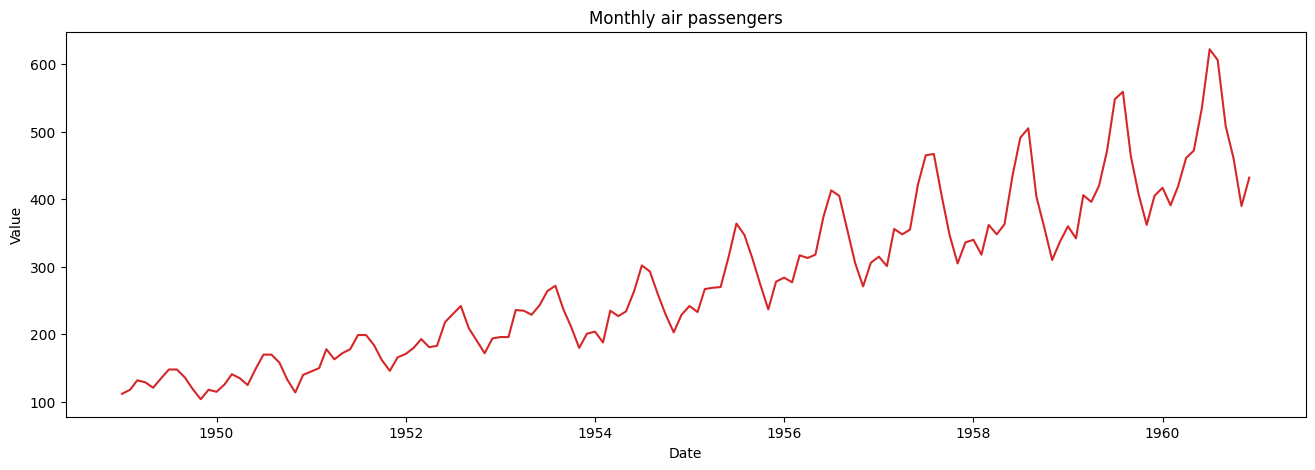

In [6]:
plot_df(df, x=df.index, y=df.value, title="Monthly air passengers")

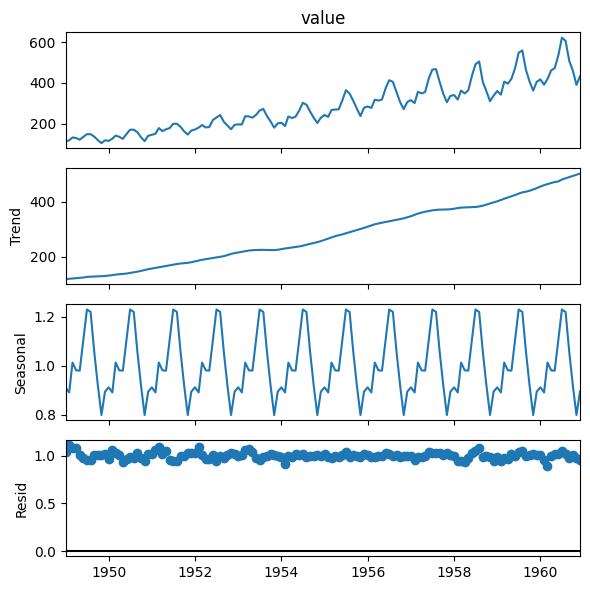

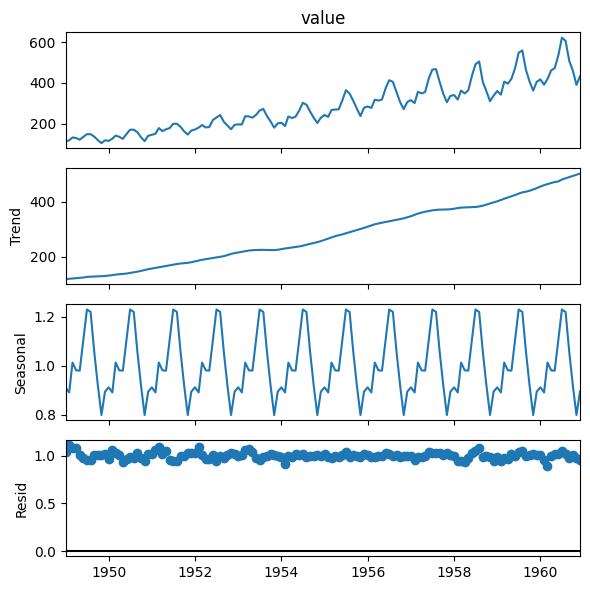

In [7]:
result_mul = seasonal_decompose(df["value"], model = "multiplicative", extrapolate_trend = "freq")
result_add = seasonal_decompose(df["value"], model = "additive", extrapolate_trend = "freq")
plt.rcParams.update({'figure.figsize': (6,6)})
result_mul.plot()

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

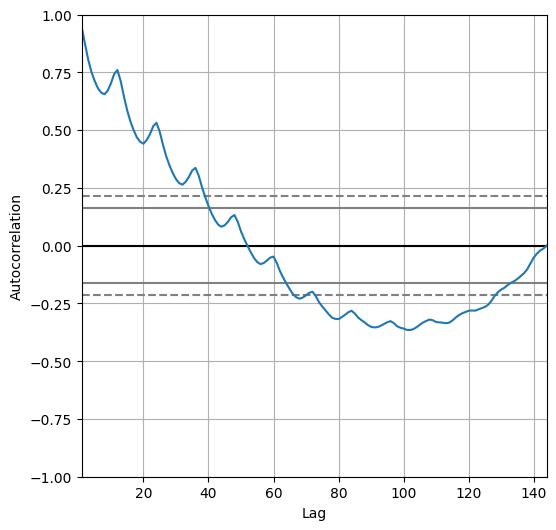

In [8]:
# Pintamos autocorrelación 
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df["value"])

## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior

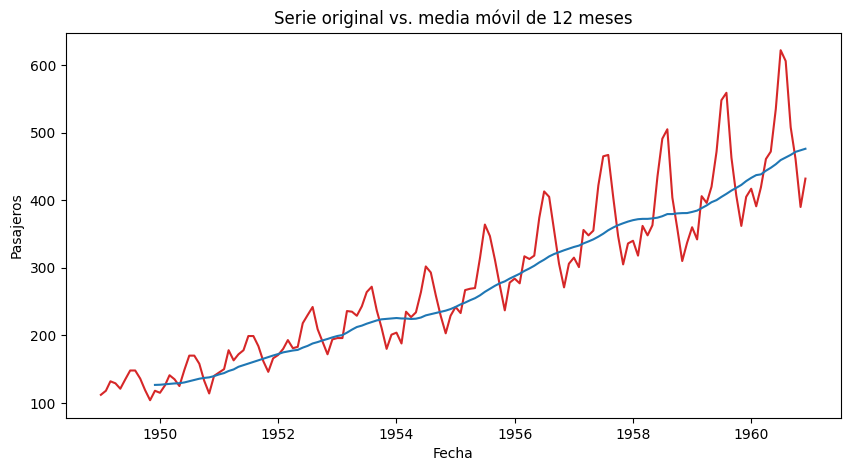

In [9]:
rolling_mean = df["value"].rolling(window=12).mean()

plt.figure(figsize=(10,5))
plt.plot(df.index, df["value"], color="tab:red", label="Serie original")
plt.plot(df.index, rolling_mean, color="tab:blue", label="Media móvil (window=12)")
plt.title("Serie original vs. media móvil de 12 meses")
plt.xlabel("Fecha")
plt.ylabel("Pasajeros")
plt.show()

## 3. Comprueba de manera estadística si la serie es o no stationary.

El test estadístico es positivo, lo cual implica que es mucho menos probable que rechacemos la hipótesis nula (no estacionaria).

Al comparar el estadístico ADF con los valores críticos, parece que no podríamos rechazar la hipótesis nula de que la serie temporal no es estacionaria y en consecuencia afirmamos que la serie tiene una estructura que sí que es dependiente del tiempo.

Un valor p por encima del umbral sugiere que no rechazamos la hipótesis nula (no estacionario).

In [10]:
result = adfuller(df["value"].values, autolag="AIC")
print(f"ADF Statistic: {result[0]:.6f}")
print(f"p-value: {result[1]:.6f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"\t{key}: {value:.3f}")

ADF Statistic: 0.815369
p-value: 0.991880
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


## 4. Aplica una transformación logarítmica

Podemos ver que el valor es mayor que los valores críticos, lo que significa que podemos rechazar la hipótesis nula y, a su vez, que la serie de tiempo no es estacionaria.

Sin embargo nos sigue interesando aplicar la transformación porque conseguimos estabilizar la varianza.

In [11]:
df["value"] = np.log(df["value"])

result = adfuller(df["value"].values, autolag="AIC")
print(f"ADF Statistic: {result[0]:.6f}")
print(f"p-value: {result[1]:.6f}")
for key, value in result[4].items():
    print(f"\t{key}: {value:.3f}")

ADF Statistic: -1.717017
p-value: 0.422367
	1%: -3.482
	5%: -2.884
	10%: -2.579


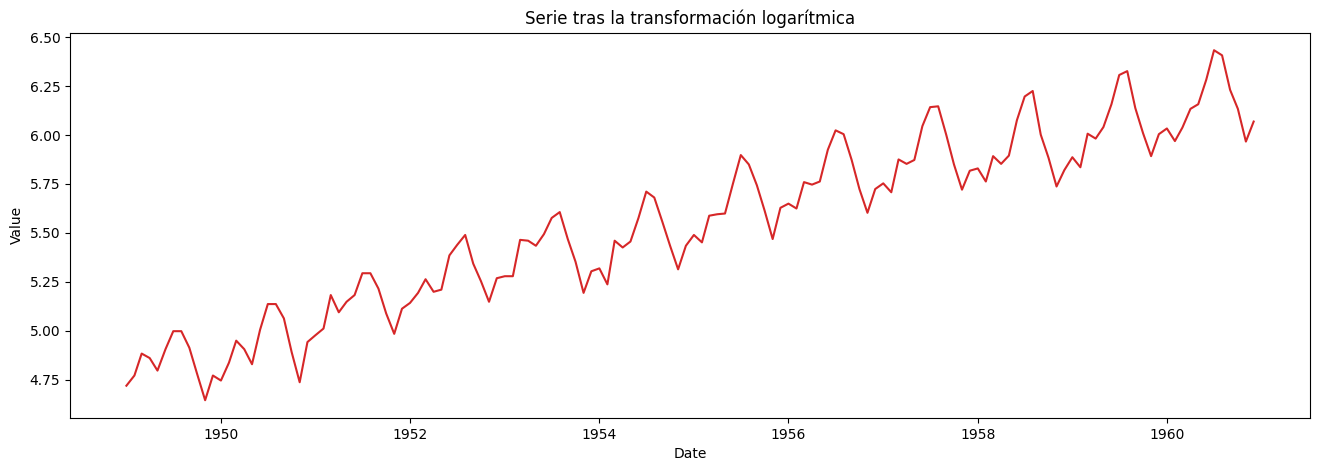

In [12]:
plot_df(df, x=df.index, y=df.value, title="Serie tras la transformación logarítmica")

## 5. Divide en train y test. Guarda 20 muestras para test.

In [13]:
train = df["value"][:-20]
test = df["value"][-20:]

print(f"Tamaño train: {len(train)}")
print(f"Tamaño test: {len(test)}")

Tamaño train: 124
Tamaño test: 20


## 6. Crea tu primer modelo ARIMA

In [14]:
model_no_season = pm.auto_arima(train,
                                start_p=1, start_q=1,
                                test="adf",
                                max_p=5, max_q=3,
                                m=1,             # sin estacionalidad
                                d=None,          # que lo decida solo
                                seasonal=False,
                                trace=True,
                                error_action="ignore",
                                suppress_warnings=True,
                                stepwise=True)

print(model_no_season.aic())

fc_no_season = model_no_season.predict(n_periods=len(test))
mse  = mean_squared_error(test, fc_no_season)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test, fc_no_season)
print(f"MSE:  {mse}")
print(f"RMSE: {rmse}")
print(f"MAE:  {mae}")

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-197.286, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=774.891, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-200.751, Time=0.14 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.18 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-200.927, Time=0.17 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.16 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-196.787, Time=0.22 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=-203.157, Time=0.22 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=-153.219, Time=0.14 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-204.447, Time=0.22 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-88.938, Time=0.08 sec

In [15]:
model = pm.auto_arima(train,
                      start_p=1, start_q=1,
                      test="adf",
                      max_p=3, max_q=3,
                      m=12,            # <-- estacionalidad anual
                      start_P=0,
                      seasonal=True,
                      d=None, D=1,
                      trace=True,
                      error_action="ignore",
                      suppress_warnings=True,
                      stepwise=True)

print(model.aic())

fc = model.predict(n_periods=len(test))
mse  = mean_squared_error(test, fc)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test, fc)
print(f"MSE:  {mse}")
print(f"RMSE: {rmse}")
print(f"MAE:  {mae}")

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=-404.047, Time=0.23 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-368.272, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-400.116, Time=0.14 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-406.420, Time=0.22 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=-378.171, Time=0.04 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=-404.733, Time=0.37 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=-404.781, Time=0.62 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=-400.976, Time=0.25 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=-403.492, Time=1.06 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=-396.821, Time=0.13 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=-404.499, Time=0.44 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=-406.061, Time=0.20 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=-402.481, Time=0.42 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=-404.459, Time=0.42 sec

Best model:  ARIMA

In [16]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  124
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 206.210
Date:                            Sat, 09 May 2026   AIC                           -406.420
Time:                                    13:16:23   BIC                           -398.291
Sample:                                01-01-1949   HQIC                          -403.122
                                     - 04-01-1959                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3429      0.085     -4.050      0.000      -0.509      -0.177
ma.S.L12      -0.5590      0.101     -5.537      0.000      -0.757      -0.361
sigma2         0.0014      0.000      8.110      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.87
Prob(Q):                              0.91   Prob(JB):                         0.65
Heteroskedasticity (H):               0.39   Skew:                             0.06
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.42
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 7. Representa en una gráfica los datos de test y tus predicciones.

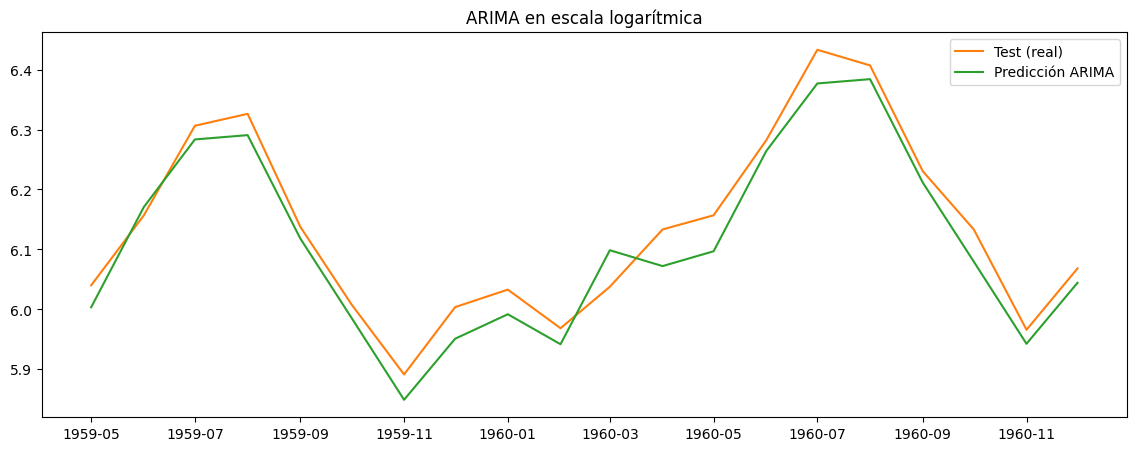

In [17]:
fc_series = pd.Series(fc, index=test.index)

plt.figure(figsize=(14,5))
plt.plot(test, label="Test (real)", color="tab:orange")
plt.plot(fc_series, label="Predicción ARIMA", color="tab:green")
plt.title("ARIMA en escala logarítmica")
plt.legend()
plt.show()

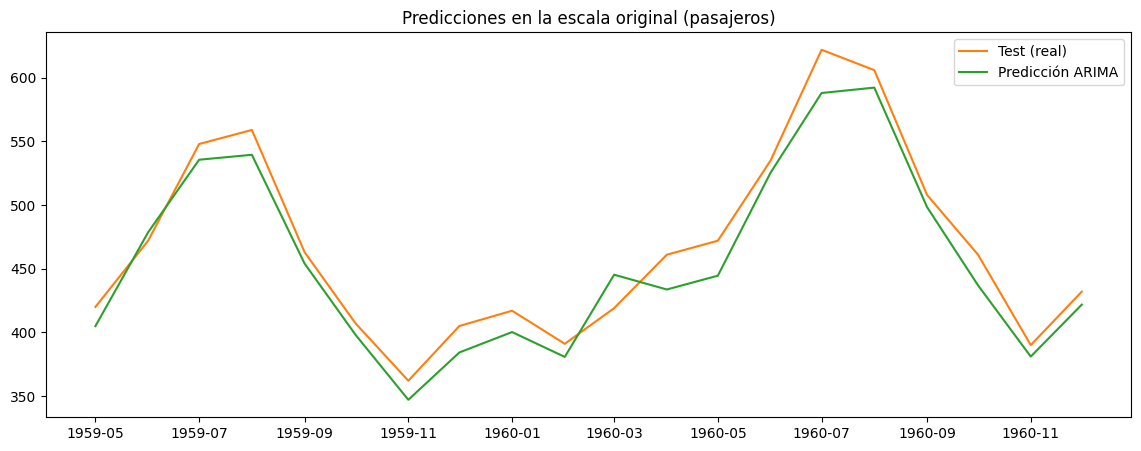

In [18]:
plt.figure(figsize=(14,5))
plt.plot(np.exp(test), label="Test (real)", color="tab:orange")
plt.plot(np.exp(fc_series), label="Predicción ARIMA", color="tab:green")
plt.title("Predicciones en la escala original (pasajeros)")
plt.legend()
plt.show()

In [19]:
test

date
1959-05-01    6.040255
1959-06-01    6.156979
1959-07-01    6.306275
1959-08-01    6.326149
1959-09-01    6.137727
1959-10-01    6.008813
1959-11-01    5.891644
1959-12-01    6.003887
1960-01-01    6.033086
1960-02-01    5.968708
1960-03-01    6.037871
1960-04-01    6.133398
1960-05-01    6.156979
1960-06-01    6.282267
1960-07-01    6.432940
1960-08-01    6.406880
1960-09-01    6.230481
1960-10-01    6.133398
1960-11-01    5.966147
1960-12-01    6.068426
Name: value, dtype: float64

## 8. Prueba otros modelos, a ver qué performance presentan.

In [20]:
df_lags = pd.DataFrame(df["value"])
for i in range(1, 13):
    df_lags[f"t-{i}"] = df_lags["value"].shift(i)

cols = ["value"] + [f"t-{i}" for i in range(12, 0, -1)]
df_lags = df_lags[cols].dropna()
df.head()

,value
date,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791


In [21]:
X = df_lags.drop(columns=["value"])
y = df_lags["value"]

X_train, X_test = X[:-19], X[-19:]
y_train, y_test = y[:-19], y[-19:]

print("Shape X_train:", X_train.shape)
print("Shape X_test:",  X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:",  y_test.shape)

Shape X_train: (113, 12)
Shape X_test: (19, 12)
Shape y_train: (113,)
Shape y_test: (19,)


In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# --- Decision Tree ---
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

mse_dt  = mean_squared_error(y_test, pred_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt  = mean_absolute_error(y_test, pred_dt)
print("--- Decision Tree ---")
print(f"MSE:  {mse_dt}")
print(f"RMSE: {rmse_dt}")
print(f"MAE:  {mae_dt}")

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mse_rf  = mean_squared_error(y_test, pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf  = mean_absolute_error(y_test, pred_rf)
print("\n--- Random Forest ---")
print(f"MSE:  {mse_rf}")
print(f"RMSE: {rmse_rf}")
print(f"MAE:  {mae_rf}")

--- Decision Tree ---
MSE:  0.011304411752783874
RMSE: 0.10632220724187338
MAE:  0.08381019761395692

--- Random Forest ---
MSE:  0.011970504307652351
RMSE: 0.10940979987026916
MAE:  0.08053741033334065


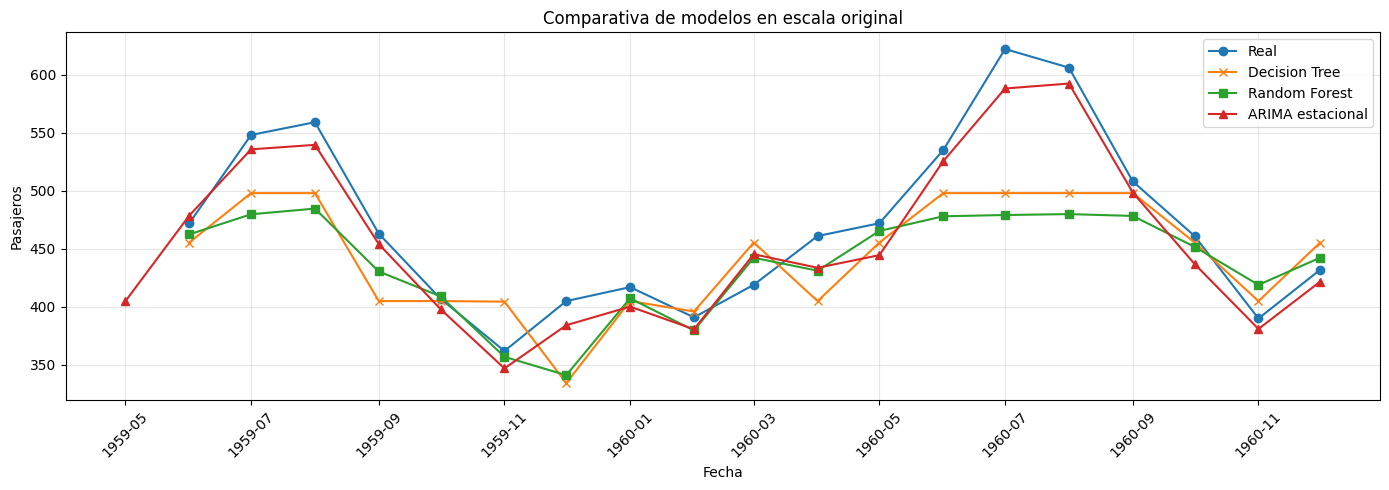

In [23]:
pred_dt_series = pd.Series(pred_dt, index=y_test.index)
pred_rf_series = pd.Series(pred_rf, index=y_test.index)

fc_series = pd.Series(fc, index=test.index)

plt.figure(figsize=(14,5))

plt.plot(y_test.index,         np.exp(y_test.values),      label="Real",             marker="o")
plt.plot(pred_dt_series.index, np.exp(pred_dt_series),     label="Decision Tree",    marker="x")
plt.plot(pred_rf_series.index, np.exp(pred_rf_series),     label="Random Forest",    marker="s")
plt.plot(fc_series.index,      np.exp(fc_series),          label="ARIMA estacional", marker="^")
plt.title("Comparativa de modelos en escala original")
plt.xlabel("Fecha")
plt.ylabel("Pasajeros")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()